# Import Library

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)

# Load Dataset

In [ ]:
X_train = pd.read_csv("/content/X_train.csv")
X_test = pd.read_csv("/content/X_test.csv")

y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

DATA LOADED
X_train: (143757, 97)
X_test : (36762, 97)


In [ ]:
# FIX TARGET SHAPE
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

y_train Shape: (143757,)
y_test Shape : (36762,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143757 entries, 0 to 143756
Data columns (total 97 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   category_name_Accessories           143757 non-null  float64
 1   category_name_As Seen on  TV!       143757 non-null  float64
 2   category_name_Baby                  143757 non-null  float64
 3   category_name_Baseball & Softball   143757 non-null  float64
 4   category_name_Basketball            143757 non-null  float64
 5   category_name_Books                 143757 non-null  float64
 6   category_name_Boxing & MMA          143757 non-null  float64
 7   category_name_CDs                   143757 non-null  float64
 8   category_name_Cameras               143757 non-null  float64
 9   category_name_Camping & Hiking      143757 non-null  float64
 10  category_name_Cardio Equipment      143757 non-null  float64
 11  category_name_Children's C

# Modeling

In [ ]:
features_to_drop = ["customer_late_rate", "customer_order_count"] # best skenario
existing_drops = [col for col in features_to_drop if col in X_train.columns]

if existing_drops:
    X_train = X_train.drop(columns=existing_drops)
    X_test = X_test.drop(columns=existing_drops, errors='ignore')
    print(f"Features removed: {existing_drops}")
else:
    print("Features not found.")


Features removed: ['customer_late_rate', 'customer_order_count']


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)
print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
# Catboost
!pip install catboost
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)
print("CatBoost training completed.")

CatBoost training completed.


# Evaluation

## Random Forest

In [ ]:
# Random Forest
# train & test predict
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
print("Prediction completed.")

Prediction completed.


with `customer_late_rate`

In [ ]:
# train metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred)

# test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_roc_auc
    ],
    "Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("Randome Forest")
print("=" * 60)

display(evaluation_df)

Randome Forest


,Metric,Train,Test,Gap
0,Accuracy,0.787398,0.688836,0.098562
1,Precision,0.797501,0.822307,-0.024805
2,Recall,0.822069,0.543667,0.278402
3,F1-Score,0.809599,0.654567,0.155031
4,ROC-AUC,0.783560,0.702243,0.081317


without `customer_late_rate`

In [ ]:
# train metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred)

# test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_roc_auc
    ],
    "Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("Random Forest (without coustomer_late_rate)")
print("=" * 60)

display(evaluation_df)

Random Forest (without coustomer_late_rate)


,Metric,Train,Test,Gap
0,Accuracy,0.705371,0.690115,0.015256
1,Precision,0.850381,0.833268,0.017113
2,Recall,0.563245,0.535741,0.027504
3,F1-Score,0.677651,0.652174,0.025477
4,ROC-AUC,0.721103,0.704371,0.016732


without `customer_late_rate` & `customer_order_count`

In [ ]:
# train metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred)

# test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_roc_auc
    ],
    "Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("Random Forest (without coustomer_late_rate & customer_order_count)")
print("=" * 60)

display(evaluation_df)

Random Forest (without coustomer_late_rate & customer_order_count)


,Metric,Train,Test,Gap
0,Accuracy,0.704049,0.690332,0.013717
1,Precision,0.849006,0.831460,0.017547
2,Recall,0.561625,0.537998,0.023627
3,F1-Score,0.676043,0.653286,0.022756
4,ROC-AUC,0.719815,0.704401,0.015414


without `customer_late_rate` & `shipping_mode_risk`

In [ ]:
# train metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred)

# test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_roc_auc
    ],
    "Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("Random Forest (without coustomer_late_rate & shipping_mode_risk)")
print("=" * 60)

display(evaluation_df)

Random Forest (without coustomer_late_rate & shipping_mode_risk)


,Metric,Train,Test,Gap
0,Accuracy,0.707082,0.689489,0.017593
1,Precision,0.844736,0.824794,0.019942
2,Recall,0.572480,0.542664,0.029817
3,F1-Score,0.682457,0.654625,0.027833
4,ROC-AUC,0.721982,0.703049,0.018933


without `customer_late_rate`, `customer_order_count` & `shipping_mode_risk`

In [ ]:
# train metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred)

# test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_roc_auc
    ],
    "Test": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("Random Forest (without coustomer_late_rate)")
print("=" * 60)

display(evaluation_df)

Random Forest (without coustomer_late_rate)


,Metric,Train,Test,Gap
0,Accuracy,0.706240,0.689163,0.017078
1,Precision,0.841497,0.818556,0.022941
2,Recall,0.573809,0.548332,0.025477
3,F1-Score,0.682338,0.656733,0.025604
4,ROC-AUC,0.720900,0.702169,0.018731


## XGBoost

with `customer_late_rate`

In [ ]:
# train & test prediction
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# train metrics
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_train_precision = precision_score(y_train, xgb_train_pred)
xgb_train_recall = recall_score(y_train, xgb_train_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, xgb_train_pred)

# test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_pred)

# comparison table
xgb_evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        xgb_train_accuracy,
        xgb_train_precision,
        xgb_train_recall,
        xgb_train_f1,
        xgb_train_roc_auc
    ],
    "Test": [
        xgb_test_accuracy,
        xgb_test_precision,
        xgb_test_recall,
        xgb_test_f1,
        xgb_test_roc_auc
    ]
})

xgb_evaluation_df["Gap"] = (xgb_evaluation_df["Train"] - xgb_evaluation_df["Test"])

print("=" * 60)
print("XGBOOST EVALUATION")
print("=" * 60)

display(xgb_evaluation_df)

XGBOOST EVALUATION


,Metric,Train,Test,Gap
0,Accuracy,0.807794,0.686823,0.120970
1,Precision,0.845017,0.820814,0.024203
2,Recall,0.796513,0.540456,0.256057
3,F1-Score,0.820049,0.651765,0.168284
4,ROC-AUC,0.809042,0.700341,0.108702


without `customer_late_rate`

In [ ]:
# train & test prediction
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# train metrics
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_train_precision = precision_score(y_train, xgb_train_pred)
xgb_train_recall = recall_score(y_train, xgb_train_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, xgb_train_pred)

# test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        xgb_train_accuracy,
        xgb_train_precision,
        xgb_train_recall,
        xgb_train_f1,
        xgb_train_roc_auc
    ],
    "Test": [
        xgb_test_accuracy,
        xgb_test_precision,
        xgb_test_recall,
        xgb_test_f1,
        xgb_test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("XGBoost (without coustomer_late_rate)")
print("=" * 60)

display(evaluation_df)

XGBoost (without coustomer_late_rate)


,Metric,Train,Test,Gap
0,Accuracy,0.715965,0.688918,0.027047
1,Precision,0.849269,0.827161,0.022107
2,Recall,0.587726,0.538952,0.048774
3,F1-Score,0.694696,0.652655,0.042041
4,ROC-AUC,0.730160,0.702768,0.027393


without `customer_late_rate` & `customer_order_count`

In [ ]:
# train & test prediction
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# train metrics
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_train_precision = precision_score(y_train, xgb_train_pred)
xgb_train_recall = recall_score(y_train, xgb_train_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, xgb_train_pred)

# test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        xgb_train_accuracy,
        xgb_train_precision,
        xgb_train_recall,
        xgb_train_f1,
        xgb_train_roc_auc
    ],
    "Test": [
        xgb_test_accuracy,
        xgb_test_precision,
        xgb_test_recall,
        xgb_test_f1,
        xgb_test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("XGBoost (without coustomer_late_rate & customer_order_count)")
print("=" * 60)

display(evaluation_df)

XGBoost (without coustomer_late_rate & customer_order_count)


,Metric,Train,Test,Gap
0,Accuracy,0.710136,0.688455,0.021680
1,Precision,0.846075,0.818920,0.027155
2,Recall,0.577959,0.546275,0.031683
3,F1-Score,0.686777,0.655373,0.031404
4,ROC-AUC,0.724767,0.701586,0.023181


without `customer_late_rate` & `shipping_mode_risk`

In [ ]:
# train & test prediction
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# train metrics
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_train_precision = precision_score(y_train, xgb_train_pred)
xgb_train_recall = recall_score(y_train, xgb_train_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, xgb_train_pred)

# test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        xgb_train_accuracy,
        xgb_train_precision,
        xgb_train_recall,
        xgb_train_f1,
        xgb_train_roc_auc
    ],
    "Test": [
        xgb_test_accuracy,
        xgb_test_precision,
        xgb_test_recall,
        xgb_test_f1,
        xgb_test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("XGBoost (without coustomer_late_rate & shipping_mode_risk)")
print("=" * 60)

display(evaluation_df)

XGBoost (without coustomer_late_rate & shipping_mode_risk)


,Metric,Train,Test,Gap
0,Accuracy,0.715694,0.689652,0.026041
1,Precision,0.848524,0.828631,0.019893
2,Recall,0.587865,0.539202,0.048662
3,F1-Score,0.694543,0.653296,0.041248
4,ROC-AUC,0.729844,0.703547,0.026297


without `customer_late_rate`, `customer_order_count` & `shipping_mode_risk`

In [ ]:
# train & test prediction
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# train metrics
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_train_precision = precision_score(y_train, xgb_train_pred)
xgb_train_recall = recall_score(y_train, xgb_train_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, xgb_train_pred)

# test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_pred)

# comparasion table
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        xgb_train_accuracy,
        xgb_train_precision,
        xgb_train_recall,
        xgb_train_f1,
        xgb_train_roc_auc
    ],
    "Test": [
        xgb_test_accuracy,
        xgb_test_precision,
        xgb_test_recall,
        xgb_test_f1,
        xgb_test_roc_auc
    ]
})
evaluation_df["Gap"] = (evaluation_df["Train"] - evaluation_df["Test"])

print("=" * 60)
print("XGBoost (without coustomer_late_rate)")
print("=" * 60)

display(evaluation_df)

XGBoost (without coustomer_late_rate)


,Metric,Train,Test,Gap
0,Accuracy,0.709621,0.689652,0.019969
1,Precision,0.845186,0.819230,0.025955
2,Recall,0.577693,0.548784,0.028909
3,F1-Score,0.686296,0.657274,0.029022
4,ROC-AUC,0.724225,0.702662,0.021563


## Catboost

with `customer_late_rate`

In [ ]:
# train & test prediction
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# train metrics
cat_train_accuracy = accuracy_score(y_train, cat_train_pred)
cat_train_precision = precision_score(y_train, cat_train_pred)
cat_train_recall = recall_score(y_train, cat_train_pred)
cat_train_f1 = f1_score(y_train, cat_train_pred)
cat_train_roc_auc = roc_auc_score(y_train, cat_train_pred)

# test metrics
cat_test_accuracy = accuracy_score(y_test, cat_test_pred)
cat_test_precision = precision_score(y_test, cat_test_pred)
cat_test_recall = recall_score(y_test, cat_test_pred)
cat_test_f1 = f1_score(y_test, cat_test_pred)
cat_test_roc_auc = roc_auc_score(y_test, cat_test_pred)

# =========================
# COMPARISON TABLE
# =========================

cat_evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        cat_train_accuracy,
        cat_train_precision,
        cat_train_recall,
        cat_train_f1,
        cat_train_roc_auc
    ],
    "Test": [
        cat_test_accuracy,
        cat_test_precision,
        cat_test_recall,
        cat_test_f1,
        cat_test_roc_auc
    ]
})

cat_evaluation_df["Gap"] = (
    cat_evaluation_df["Train"] - cat_evaluation_df["Test"]
    )

print("=" * 60)
print("CATBOOST EVALUATION")
print("=" * 60)

display(cat_evaluation_df)

CATBOOST EVALUATION


,Metric,Train,Test,Gap
0,Accuracy,0.796754,0.688891,0.107864
1,Precision,0.834668,0.825145,0.009522
2,Recall,0.786050,0.540908,0.245143
3,F1-Score,0.809630,0.653456,0.156174
4,ROC-AUC,0.797939,0.702557,0.095382


without `customer_late_rate'

In [ ]:
# train & test prediction
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# train metrics
cat_train_accuracy = accuracy_score(y_train, cat_train_pred)
cat_train_precision = precision_score(y_train, cat_train_pred)
cat_train_recall = recall_score(y_train, cat_train_pred)
cat_train_f1 = f1_score(y_train, cat_train_pred)
cat_train_roc_auc = roc_auc_score(y_train, cat_train_pred)

# test metrics
cat_test_accuracy = accuracy_score(y_test, cat_test_pred)
cat_test_precision = precision_score(y_test, cat_test_pred)
cat_test_recall = recall_score(y_test, cat_test_pred)
cat_test_f1 = f1_score(y_test, cat_test_pred)
cat_test_roc_auc = roc_auc_score(y_test, cat_test_pred)

# =========================
# COMPARISON TABLE
# =========================

cat_evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        cat_train_accuracy,
        cat_train_precision,
        cat_train_recall,
        cat_train_f1,
        cat_train_roc_auc
    ],
    "Test": [
        cat_test_accuracy,
        cat_test_precision,
        cat_test_recall,
        cat_test_f1,
        cat_test_roc_auc
    ]
})

cat_evaluation_df["Gap"] = (
    cat_evaluation_df["Train"] - cat_evaluation_df["Test"]
    )

print("=" * 60)
print("catboost (without customer_late_rate)")
print("=" * 60)

display(cat_evaluation_df)

catboost (without customer_late_rate)


,Metric,Train,Test,Gap
0,Accuracy,0.707082,0.689816,0.017267
1,Precision,0.847618,0.832709,0.014908
2,Recall,0.569672,0.535591,0.034081
3,F1-Score,0.681391,0.651891,0.029499
4,ROC-AUC,0.722292,0.704058,0.018234


without `customer_late_rate` & `customer_order_count`

In [ ]:
# train & test prediction
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# train metrics
cat_train_accuracy = accuracy_score(y_train, cat_train_pred)
cat_train_precision = precision_score(y_train, cat_train_pred)
cat_train_recall = recall_score(y_train, cat_train_pred)
cat_train_f1 = f1_score(y_train, cat_train_pred)
cat_train_roc_auc = roc_auc_score(y_train, cat_train_pred)

# test metrics
cat_test_accuracy = accuracy_score(y_test, cat_test_pred)
cat_test_precision = precision_score(y_test, cat_test_pred)
cat_test_recall = recall_score(y_test, cat_test_pred)
cat_test_f1 = f1_score(y_test, cat_test_pred)
cat_test_roc_auc = roc_auc_score(y_test, cat_test_pred)

# =========================
# COMPARISON TABLE
# =========================

cat_evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        cat_train_accuracy,
        cat_train_precision,
        cat_train_recall,
        cat_train_f1,
        cat_train_roc_auc
    ],
    "Test": [
        cat_test_accuracy,
        cat_test_precision,
        cat_test_recall,
        cat_test_f1,
        cat_test_roc_auc
    ]
})

cat_evaluation_df["Gap"] = (
    cat_evaluation_df["Train"] - cat_evaluation_df["Test"]
    )

print("=" * 60)
print("catboost (without customer_late_rate & customer_order_count)")
print("=" * 60)

display(cat_evaluation_df)

catboost (without customer_late_rate & customer_order_count)


,Metric,Train,Test,Gap
0,Accuracy,0.704251,0.690360,0.013891
1,Precision,0.844351,0.825419,0.018932
2,Recall,0.566547,0.544068,0.022479
3,F1-Score,0.678099,0.655843,0.022257
4,ROC-AUC,0.719494,0.703870,0.015624


without `customer_late_rate` & `shipping_mode_risk`

In [ ]:
# train & test prediction
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# train & test prediction
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# train metrics
cat_train_accuracy = accuracy_score(y_train, cat_train_pred)
cat_train_precision = precision_score(y_train, cat_train_pred)
cat_train_recall = recall_score(y_train, cat_train_pred)
cat_train_f1 = f1_score(y_train, cat_train_pred)
cat_train_roc_auc = roc_auc_score(y_train, cat_train_pred)

# test metrics
cat_test_accuracy = accuracy_score(y_test, cat_test_pred)
cat_test_precision = precision_score(y_test, cat_test_pred)
cat_test_recall = recall_score(y_test, cat_test_pred)
cat_test_f1 = f1_score(y_test, cat_test_pred)
cat_test_roc_auc = roc_auc_score(y_test, cat_test_pred)

# =========================
# COMPARISON TABLE
# =========================

cat_evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        cat_train_accuracy,
        cat_train_precision,
        cat_train_recall,
        cat_train_f1,
        cat_train_roc_auc
    ],
    "Test": [
        cat_test_accuracy,
        cat_test_precision,
        cat_test_recall,
        cat_test_f1,
        cat_test_roc_auc
    ]
})

cat_evaluation_df["Gap"] = (
    cat_evaluation_df["Train"] -
    cat_evaluation_df["Test"]
)

print("=" * 60)
print("Catboost without customer_late_rate & shipping_mode_risk")
print("=" * 60)

display(cat_evaluation_df)

Catboost without customer_late_rate & shipping_mode_risk


,Metric,Train,Test,Gap
0,Accuracy,0.707179,0.689788,0.017391
1,Precision,0.846679,0.832385,0.014294
2,Recall,0.570798,0.535841,0.034956
3,F1-Score,0.681891,0.651978,0.029914
4,ROC-AUC,0.722276,0.704006,0.018270


without `customer_late_rate`, `customer_order_count` & `shipping_mode_risk`

In [ ]:
# train & test prediction
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# train metrics
cat_train_accuracy = accuracy_score(y_train, cat_train_pred)
cat_train_precision = precision_score(y_train, cat_train_pred)
cat_train_recall = recall_score(y_train, cat_train_pred)
cat_train_f1 = f1_score(y_train, cat_train_pred)
cat_train_roc_auc = roc_auc_score(y_train, cat_train_pred)

# test metrics
cat_test_accuracy = accuracy_score(y_test, cat_test_pred)
cat_test_precision = precision_score(y_test, cat_test_pred)
cat_test_recall = recall_score(y_test, cat_test_pred)
cat_test_f1 = f1_score(y_test, cat_test_pred)
cat_test_roc_auc = roc_auc_score(y_test, cat_test_pred)

# =========================
# COMPARISON TABLE
# =========================

cat_evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Train": [
        cat_train_accuracy,
        cat_train_precision,
        cat_train_recall,
        cat_train_f1,
        cat_train_roc_auc
    ],
    "Test": [
        cat_test_accuracy,
        cat_test_precision,
        cat_test_recall,
        cat_test_f1,
        cat_test_roc_auc
    ]
})

cat_evaluation_df["Gap"] = (
    cat_evaluation_df["Train"] - cat_evaluation_df["Test"]
    )

print("=" * 60)
print("catboost without customer_late_rate, customer_order_count & shipping_mode_risk")
print("=" * 60)

display(cat_evaluation_df)

catboost without customer_late_rate, customer_order_count & shipping_mode_risk


,Metric,Train,Test,Gap
0,Accuracy,0.704126,0.690006,0.014120
1,Precision,0.843198,0.824701,0.018496
2,Recall,0.567395,0.543968,0.023427
3,F1-Score,0.678333,0.655543,0.022790
4,ROC-AUC,0.719261,0.703493,0.015768


## Clasification Report

Random Forest

In [ ]:
# classification report
report = classification_report(
    y_test,
    y_test_pred
)

print("Random Forest report")
print(report)

Random Forest report
              precision    recall  f1-score   support

           0       0.61      0.87      0.72     16827
           1       0.83      0.54      0.65     19935

    accuracy                           0.69     36762
   macro avg       0.72      0.70      0.69     36762
weighted avg       0.73      0.69      0.68     36762



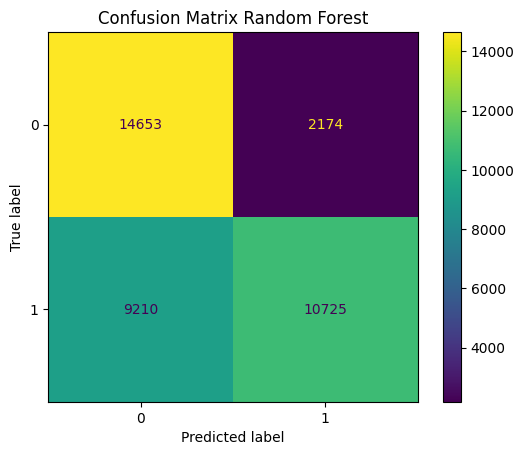

In [ ]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix Random Forest")
plt.show()

xgboost

In [ ]:
# classification report
report = classification_report(
    y_test,
    xgb_test_pred
)

print("XGBoost report")
print(report)

XGBoost report
              precision    recall  f1-score   support

           0       0.61      0.86      0.72     16827
           1       0.82      0.55      0.66     19935

    accuracy                           0.69     36762
   macro avg       0.72      0.70      0.69     36762
weighted avg       0.73      0.69      0.68     36762



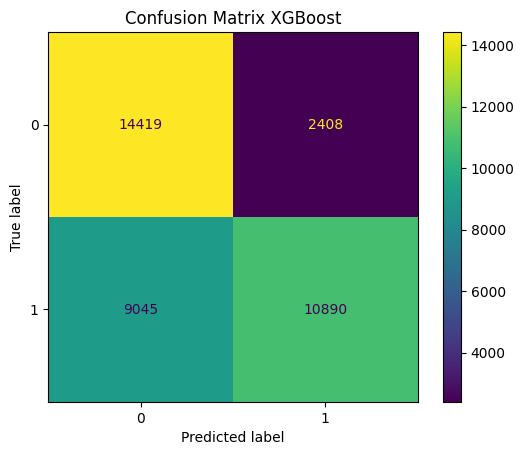

In [ ]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix XGBoost")
plt.show()

catboost

In [ ]:
# classification report
report = classification_report(
    y_test,
    cat_test_pred
)

print("Catboost report")
print(report)

Catboost report
              precision    recall  f1-score   support

           0       0.62      0.86      0.72     16827
           1       0.83      0.54      0.66     19935

    accuracy                           0.69     36762
   macro avg       0.72      0.70      0.69     36762
weighted avg       0.73      0.69      0.68     36762



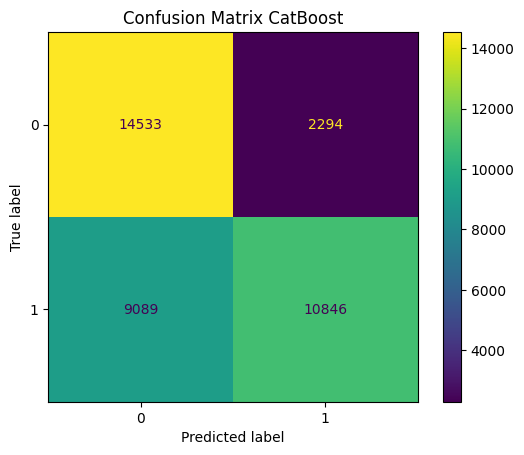

In [ ]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    cat_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix CatBoost")
plt.show()

## Feature Importance

In [ ]:
# feature importance
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
)

print("=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)

display(
    feature_importance_df.head(20)
)

TOP 20 FEATURE IMPORTANCE


,feature,importance
92,shipping_mode_risk,0.259342
85,days_for_shipment_(scheduled),0.240077
84,shipping_mode_Standard Class,0.187421
81,shipping_mode_First Class,0.165231
83,shipping_mode_Second Class,0.065365
82,shipping_mode_Same Day,0.020543
86,benefit_per_order,0.010624
89,order_month,0.006363
90,order_dayofweek,0.006358
88,sales,0.004556


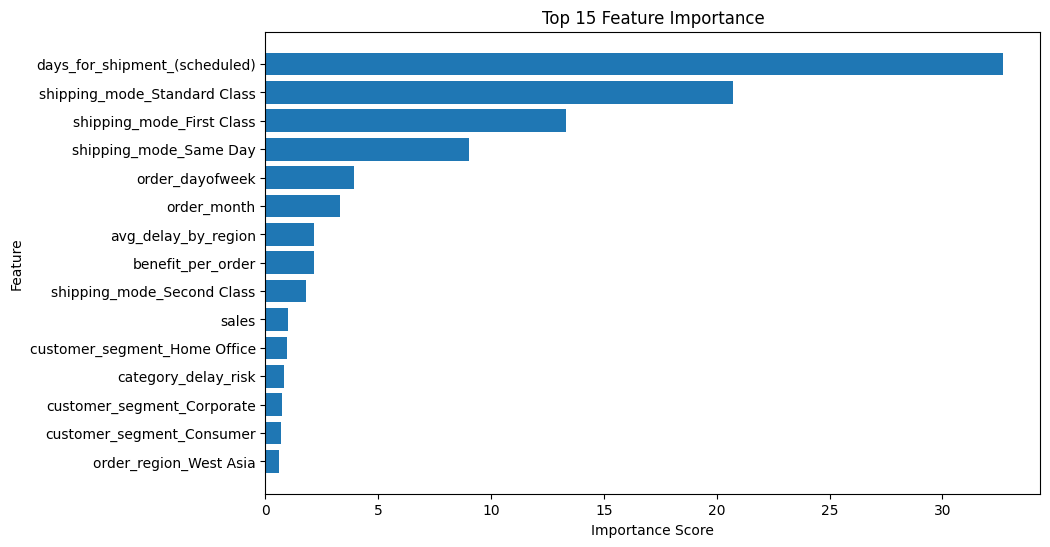

In [ ]:
# feature importance visualitation
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
# save model
os.makedirs(
    "/content/artifacts/models",
    exist_ok=True
)

model_path = (
    "/content/artifacts/models/random_forest.pkl"
)

joblib.dump(
    rf_model,
    model_path
)

print("=" * 60)
print("MODEL SAVED")
print("=" * 60)

print(f"Saved to:\n{model_path}")

MODEL SAVED
Saved to:
/content/artifacts/models/random_forest.pkl
